# Phase 2 — Preprocessing & Feature Engineering

### Objectifs
1. Pipeline sklearn (imputation, encoding, scaling)
2. Feature engineering (ratios, interactions)
3. Split train/test stratifié

Ce notebook utilise le module `backend.data.preprocessing` pour garantir
que le même code sera réutilisé par l'API.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Ajouter la racine du projet au path pour importer backend.*
sys.path.insert(0, os.path.abspath('..'))

from backend.data.preprocessing import (
    add_engineered_features, build_preprocessor, load_and_split,
    get_feature_names, NUM_COLS, CAT_COLS_ONEHOT, CAT_COLS_ORDINAL,
    ENGINEERED_COLS, TARGET, ID_COL,
)

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)

FIGURES_DIR   = '../reports/figures/'
ARTIFACTS_DIR = '../artifacts/'

## 1. Chargement & Feature Engineering

On utilise `load_and_split()` qui enchaîne :
1. Lecture du CSV
2. `add_engineered_features()` — revenue_per_month, tickets_per_tenure, login_intensity
3. Split stratifié 80/20

In [2]:
X_train, X_test, y_train, y_test = load_and_split('../customer_churn.csv')

# Aperçu des features engineered
print('\nAperçu des features engineered (train) :')
X_train[ENGINEERED_COLS].describe().round(3)

Train : (8000, 33) | Churn rate: 10.2%
Test  : (2000, 33)  | Churn rate: 10.2%

Aperçu des features engineered (train) :


,revenue_per_month,tickets_per_tenure,login_intensity
count,8000.000,8000.000,8000.000
mean,34.880,0.096,6.240
std,23.821,0.251,6.962
min,10.000,0.000,0.000
25%,20.000,0.000,2.000
50%,30.000,0.034,4.250
75%,50.000,0.077,7.688
max,100.000,5.000,51.000


## 2. Corrélation des features avec le Churn

Visualisation de l'apport des features engineered vs. les features brutes.

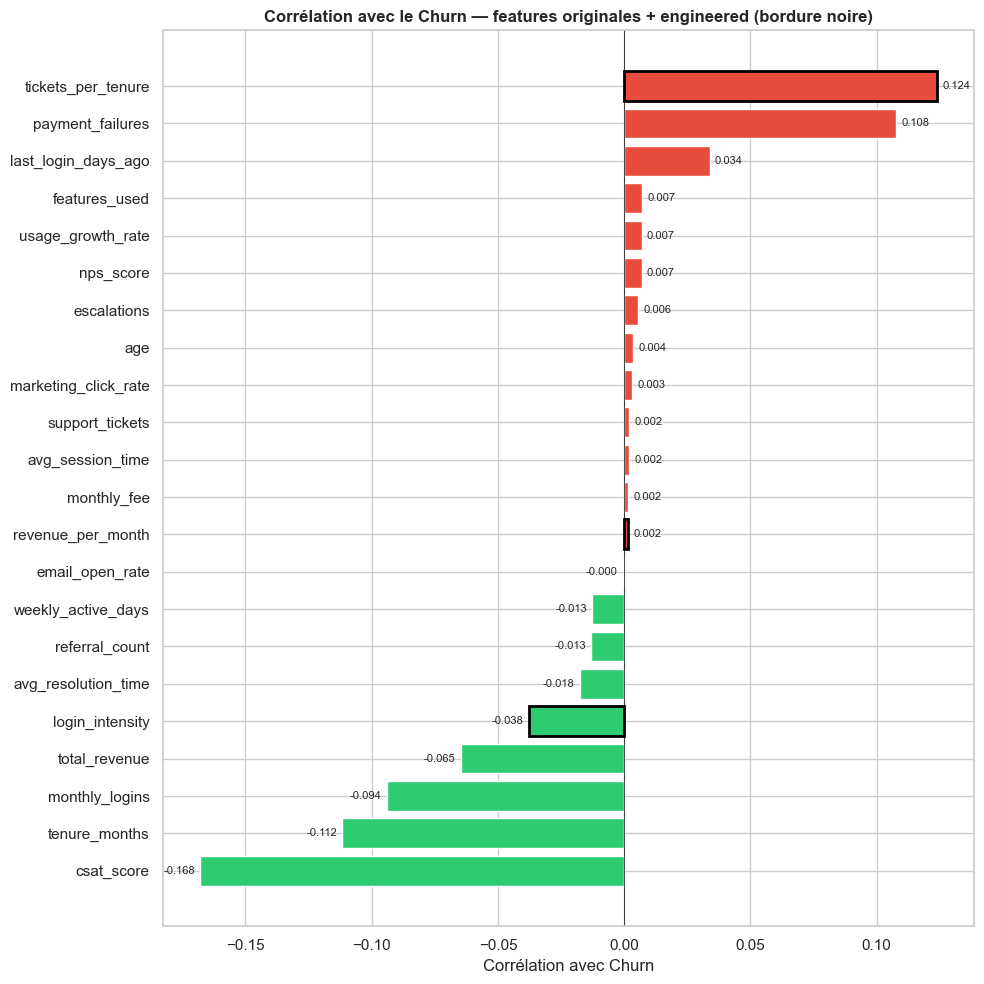

In [3]:
# Reconstituer un DataFrame complet pour la visualisation
df_viz = X_train.copy()
df_viz['churn'] = y_train.values

all_num = [c for c in df_viz.columns if c not in CAT_COLS_ONEHOT + CAT_COLS_ORDINAL + ['churn']]
corr_churn = df_viz[all_num].corrwith(df_viz['churn']).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_churn.values]
bars = ax.barh(corr_churn.index, corr_churn.values, color=colors)

for i, (name, val) in enumerate(zip(corr_churn.index, corr_churn.values)):
    if name in ENGINEERED_COLS:
        bars[i].set_edgecolor('black')
        bars[i].set_linewidth(2)
    ax.text(val + (0.002 if val > 0 else -0.002), i, f'{val:.3f}',
            va='center', ha='left' if val > 0 else 'right', fontsize=8)

ax.set_xlabel('Corrélation avec Churn')
ax.set_title('Corrélation avec le Churn — features originales + engineered (bordure noire)',
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}correlation_churn_fe.png', bbox_inches='tight')
plt.show()

## 3. Construction et fit du Pipeline sklearn

Le pipeline est construit par `build_preprocessor()` du module :
- **Numérique** : SimpleImputer(median) + StandardScaler
- **OneHot** : SimpleImputer(constant='No_Complaint') + OneHotEncoder
- **Ordinal** : SimpleImputer(most_frequent) + OrdinalEncoder

Le `fit` se fait **uniquement sur le train** pour éviter le data leakage.

In [4]:
preprocessor = build_preprocessor()

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor)

print(f'X_train transformé : {X_train_processed.shape}')
print(f'X_test  transformé : {X_test_processed.shape}')
print(f'Features : {len(feature_names)}')

X_train transformé : (8000, 57)
X_test  transformé : (2000, 57)
Features : 57


## 4. Vérification du scaling

In [5]:
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

num_check = X_train_df[NUM_COLS[:6]].describe().round(3)
print('Statistiques des 6 premières features numériques après scaling :')
print(num_check)
print('\n=> mean ≈ 0, std ≈ 1 : scaling correct')

Statistiques des 6 premières features numériques après scaling :
            age  tenure_months  monthly_logins  weekly_active_days  \
count  8000.000       8000.000        8000.000            8000.000   
mean      0.000          0.000          -0.000               0.000   
std       1.000          1.000           1.000               1.000   
min      -1.704         -1.709          -2.013              -1.516   
25%      -0.850         -0.833          -0.687              -1.082   
50%       0.003         -0.015           0.027               0.220   
75%       0.857          0.862           0.640               1.087   
max       1.710          1.680           3.496               1.521   

       avg_session_time  features_used  
count          8000.000       8000.000  
mean              0.000         -0.000  
std               1.000          1.000  
min              -2.087         -1.806  
25%              -0.708         -0.905  
50%              -0.001         -0.003  
75%              

## 5. Sauvegarde des artifacts

In [6]:
joblib.dump(preprocessor, f'{ARTIFACTS_DIR}preprocessor.joblib')
np.save(f'{ARTIFACTS_DIR}X_train.npy', X_train_processed)
np.save(f'{ARTIFACTS_DIR}X_test.npy',  X_test_processed)
np.save(f'{ARTIFACTS_DIR}y_train.npy', y_train.values)
np.save(f'{ARTIFACTS_DIR}y_test.npy',  y_test.values)

with open(f'{ARTIFACTS_DIR}feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(f'Preprocesseur : {ARTIFACTS_DIR}preprocessor.joblib')
print(f'X_train       : {X_train_processed.shape}')
print(f'X_test        : {X_test_processed.shape}')
print(f'Features      : {len(feature_names)}')

Preprocesseur : ../artifacts/preprocessor.joblib
X_train       : (8000, 57)
X_test        : (2000, 57)
Features      : 57


## 6. Synthèse Phase 2

| Étape | Action | Justification |
|-------|--------|---------------|
| **Feature Engineering** | 3 features dérivées (ratios) | Réduire redondance, capturer intensité |
| **Suppression** | `customer_id`, `total_revenue` | Pas de valeur prédictive / redondant |
| **Split stratifié** | 80% train / 20% test | Conserver le ratio churn dans chaque split |
| **Imputation** | Médiane (num), constante (cat) | Robuste aux outliers, encode l'absence de plainte |
| **Encoding** | OneHot (nominal + binaire), Ordinal (ordinal) | Adapté au type de variable |
| **Scaling** | StandardScaler | Nécessaire pour Logistic Regression |
| **Module** | `backend.data.preprocessing` | Code réutilisable par l'API, évite la duplication |
